# Прогнозирование урожайности Пензенской области — модели 

**Культуры:** зерновые, сахарная свёкла, подсолнечник, картофель, овощи  
**Период:** 1990–2025 (36 лет) · **Метрика:** MAPE · **Схема:** expanding window backtesting

| Культура | MAPE v2 | MAPE  | Δ | Ключевые изменения  |
|---|---|---|---|---|
| Зерновые | 9.14% | **9.14%** | — | без изменений |
| Сахарная свёкла | 9.37% | **6.52%** | −2.85 п.п. | min_train 11→12 |
| Подсолнечник | 15.75% | **15.18%** / 13.15%* | −0.57 п.п. | убран нестабильный ma3, +rf_sum_apr, +swc_m06 |
| Картофель | 11.16% | **9.74%** | −1.42 п.п. | min_train 11→12, +solar_rad_m08, +log_s_potato |
| Овощи | 8.28% | **8.10%** | −0.18 п.п. | без изменений |

\* Подсолнечник 2017 исключён из метрики (организационная причина, не климатическая).

## 0. Загрузка данных и конфигураций 

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error
from scipy import stats as scipy_stats

plt.rcParams.update({'figure.dpi':120,'font.size':10,
    'axes.titlesize':11,'axes.titleweight':'bold','axes.grid':True,'grid.alpha':0.3})

xl = pd.ExcelFile('penza_dataset_2025.xlsx')
frames = []
for sheet in xl.sheet_names:
    if sheet in {'Примечания','Сводный_ML'}: continue
    sh = xl.parse(sheet, index_col=0)
    sh.index.name='Год'; sh.index=sh.index.astype(int)
    for c in sh.select_dtypes(exclude=['datetime','object']).columns:
        sh[c]=pd.to_numeric(sh[c],errors='coerce')
    frames.append(sh)
df=pd.concat(frames,axis=1).sort_index(); df=df.loc[:,~df.columns.duplicated()]
df.loc[2013,'s_sunflower']=174.3; df.loc[2013,'w_sunflower']=248.73
df.loc[2013,'p_sunflower']=round(248.73/174.3,4)

for c in [col for col in df.columns if col.startswith('pet_mm_')]: df[c+'_abs']=df[c].abs()
if 'ndvi_peak' not in df.columns:
    pk=[c for c in ['ndvi_m06','ndvi_m07','ndvi_m08'] if c in df.columns]
    if pk: df['ndvi_peak']=df[pk].max(axis=1)
    ja=[c for c in ['ndvi_m07','ndvi_m08'] if c in df.columns]
    if ja: df['ndvi_jul_aug']=df[ja].mean(axis=1)
    vg=[c for c in ['ndvi_m05','ndvi_m06','ndvi_m07','ndvi_m08','ndvi_m09'] if c in df.columns]
    if vg: df['ndvi_veget']=df[vg].mean(axis=1)
    if 'ndvi_m06' in df.columns and 'ndvi_m07' in df.columns:
        df['ndvi_drop_jul']=df['ndvi_m06']-df['ndvi_m07']
    for col in ['ndvi_peak','ndvi_jul_aug','ndvi_veget']:
        if col in df.columns: df[col+'_anom']=df[col]-df[col].mean()
if 'snow_water_eq_mm_m12' in df.columns: df['snow_weq_dec_lag1']=df['snow_water_eq_mm_m12'].shift(1)
swc_spr=['swc_7_28cm_m03','swc_7_28cm_m04','swc_7_28cm_m05']
if all(c in df.columns for c in swc_spr): df['era5_spring_recharge']=df[swc_spr].mean(axis=1)
frost_c=['soil_temp_0_7cm_m01','soil_temp_0_7cm_m02']
if all(c in df.columns for c in frost_c): df['frost_risk']=df[frost_c].min(axis=1)
for cult in ['grain_crops','sugar_beet','sunflower','potato','vegetables']:
    col='p_'+cult
    for lag in [1,2,3]: df[col+'_lag'+str(lag)]=df[col].shift(lag)
    for w in [3,5]: df[col+'_ma'+str(w)]=df[col].rolling(w,min_periods=w-1).mean().shift(1)
    if 's_'+cult in df.columns: df['s_'+cult+'_lag1']=df['s_'+cult].shift(1)
df['time_index']=np.arange(len(df)); df['time_index_sq']=df['time_index']**2
df['rf_sum_summer']=df[['rf_sum_jun','rf_sum_jul','rf_sum_aug']].sum(axis=1)
df['mean_temp_summer']=df[['mean_temp_jun','mean_temp_jul','mean_temp_aug']].mean(axis=1)
df['rf_sum_spring']=df[['rf_sum_apr','rf_sum_may','rf_sum_jun']].sum(axis=1)
df['mean_temp_spring']=df[['mean_temp_apr','mean_temp_may']].mean(axis=1)
df['rf_sum_autumn']=df[['rf_sum_sep','rf_sum_oct','rf_sum_nov']].sum(axis=1)
df['GTK_sq']=df['GTK']**2; df['GTK_x_SAT']=df['GTK']*df['SAT']
df['heat_x_moisture']=df['mean_temp_summer']*df['veget_precip']
df['water_deficit']=(df['evaporation']-df['veget_precip']).clip(lower=0)
df['drought_severity']=np.clip((1.0-df['GTK'])/0.6,0,1)
df['excess_moisture']=np.clip((df['GTK']-1.3)/0.2,0,1)
df['rf_aug_critical']=df['rf_sum_aug']/(df['mean_temp_aug']-10).clip(lower=1)
df['temp_x_precip_jul']=df['mean_temp_jul']*df['rf_sum_jul']
df['temp_x_precip_aug']=df['mean_temp_aug']*df['rf_sum_aug']
df['temp_x_precip_sep']=df['mean_temp_sep']*df['rf_sum_sep']
df['harvest_difficulty']=(df['rf_sum_oct']*1.5+df['rf_sum_sep'])/df['mean_temp_oct'].clip(lower=1)
df['log_s_potato_lag1']=np.log(df['s_potato'].shift(1))

target_cols=['p_grain_crops','p_sugar_beet','p_sunflower','p_potato','p_vegetables']
labels={'p_grain_crops':'Зерновые','p_sugar_beet':'Сахарная свёкла',
        'p_sunflower':'Подсолнечник','p_potato':'Картофель','p_vegetables':'Овощи'}
colors={'p_grain_crops':'#2196F3','p_sugar_beet':'#4CAF50',
        'p_sunflower':'#FF9800','p_potato':'#9C27B0','p_vegetables':'#F44336'}
DROUGHT_YEARS=[yr for yr in df.index if 'GTK' in df.columns and df.loc[yr,'GTK']<0.70]

configs={}
for t in target_cols:
    with open(f'grid_v3/best_{t}_v3.json') as f: configs[t]=json.load(f)

def backtest(feats,target,decay,mt,alpha):
    feats=[f for f in feats if f in df.columns]
    sub=df[[target]+feats].dropna(); years=sub.index.tolist()
    p,a,y=[],[],[]
    for i in range(mt,len(years)):
        tr,te=years[:i],years[i]
        w=np.array([decay**(tr[-1]-yr) for yr in tr]); w=w/w.sum()*len(w)
        sc=StandardScaler(); r=Ridge(alpha=alpha)
        r.fit(sc.fit_transform(sub.loc[tr,feats]),sub.loc[tr,target],sample_weight=w)
        p.append(r.predict(sc.transform(sub.loc[[te],feats]))[0])
        a.append(sub.loc[te,target]); y.append(te)
    pa,aa=np.array(p),np.array(a)
    return {'preds':pa,'actuals':aa,'years':y,
            'mape':mean_absolute_percentage_error(aa,pa)*100,
            'mae': mean_absolute_error(aa,pa)}

print('Датасет: {} лет ({}–{})'.format(len(df),df.index.min(),df.index.max()))
for t,cfg in configs.items():
    n=len([f for f in cfg['base']+cfg['extra'] if f in df.columns])
    print('  {:<22} MAPE={:.2f}%  mt={}  n={}'.format(cfg['label'],cfg['mape'],cfg['min_train'],n))


Датасет: 36 лет (1990–2025)
  Зерновые               MAPE=9.14%  mt=11  n=17
  Сахарная свёкла        MAPE=6.52%  mt=12  n=31
  Подсолнечник           MAPE=15.18%  mt=11  n=23
  Картофель              MAPE=9.74%  mt=12  n=32
  Овощи                  MAPE=8.10%  mt=10  n=22


## 1–5. Динамика урожайности и ретро-прогноз 

**Верхняя панель:** факт · тренд МНК (серая пунктирная) · ретро-прогноз  (красная пунктирная) · оранжевые полосы — GTK < 0.70.  
**Нижняя панель:** абсолютная ошибка прогноза по годам. Цвет: синий ≤ 10% · оранжевый 10–20% · красный > 20%.  
Оси X обеих панелей синхронизированы — одинаковые засечки и диапазон.

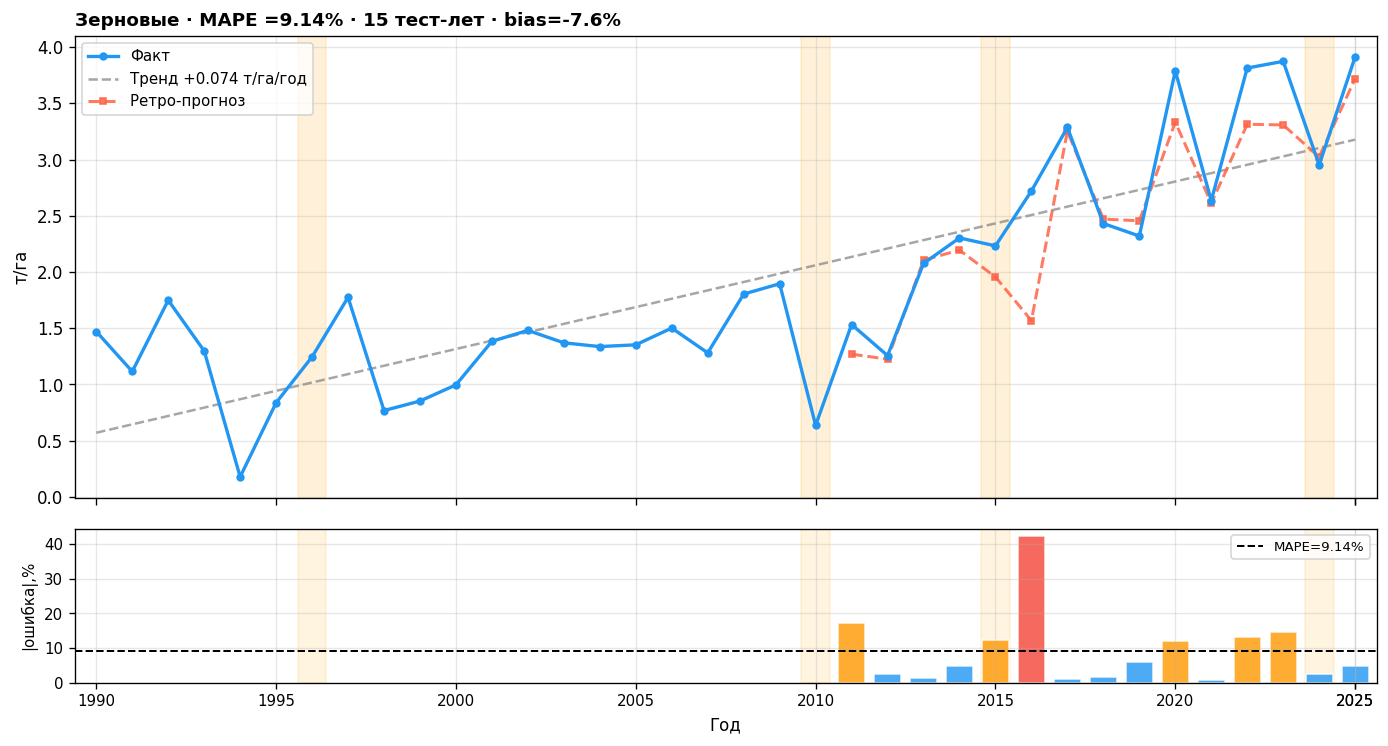

Зерновые: MAPE=9.14%  MAE=0.259 т/га  bias=-7.6%  n-тест=15


In [15]:
cfg   = configs['p_grain_crops']
feats = [f for f in cfg['base']+cfg['extra'] if f in df.columns]
res   = backtest(feats,'p_grain_crops',cfg['decay'],cfg['min_train'],cfg['alpha'])
p,a,y = res['preds'],res['actuals'],res['years']
bias  = np.mean((p-a)/a*100)
mape_yr=[abs(pi-ai)/ai*100 for pi,ai in zip(p,a)]

y_full=df['p_grain_crops'].dropna()
ti=np.arange(len(y_full))
lr=LinearRegression().fit(ti.reshape(-1,1),y_full.values)
slope=lr.coef_[0]

c=colors['p_grain_crops']; lbl=labels['p_grain_crops']

# Общий диапазон X для обеих панелей
x_min=int(y_full.index.min())-0.6
x_max=int(y_full.index.max())+0.6
# Засечки: каждые 5 лет
x_ticks=[yr for yr in range(1990,2026,5)]+[2025]

fig,(ax1,ax2)=plt.subplots(2,1,figsize=(14,7),
    gridspec_kw={'height_ratios':[3,1],'hspace':0.10})

# ── Засухи ─────────────────────────────────────────────────────
for yr in DROUGHT_YEARS:
    if yr in y_full.index:
        ax1.axvspan(yr-.4,yr+.4,color='orange',alpha=0.15,zorder=0)
        ax2.axvspan(yr-.4,yr+.4,color='orange',alpha=0.12,zorder=0)

# ── Верхняя панель ─────────────────────────────────────────────
ax1.plot(y_full.index,y_full.values,color=c,lw=2,marker='o',ms=4,zorder=3,label='Факт')
ax1.plot(y_full.index,lr.predict(ti.reshape(-1,1)),'--',color='gray',lw=1.5,alpha=0.7,
    label='Тренд {:+.3f} т/га/год'.format(slope))
ax1.plot(y,p,'s--',color='tomato',lw=1.8,ms=4,alpha=0.85,label='Ретро-прогноз ')
pass  # нет аннотаций
ax1.set_ylabel('т/га',fontsize=10)
ax1.set_xlim(x_min,x_max)
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([])          # подписи скрыты — они продублированы на нижней панели
ax1.legend(fontsize=9,loc='upper left')
ax1.set_title(lbl+' · MAPE ={:.2f}% · {} тест-лет · bias={:+.1f}%'.format(
    res['mape'],len(y),bias),fontsize=11,fontweight='bold',loc='left')
ax1.tick_params(axis='x',length=4)

# ── Нижняя панель ──────────────────────────────────────────────
bc=['#F44336' if e>20 else '#FF9800' if e>10 else c for e in mape_yr]
ax2.bar(y,mape_yr,color=bc,alpha=0.8,width=0.75,edgecolor='white')
ax2.axhline(res['mape'],color='black',ls='--',lw=1.2,
    label='MAPE={:.2f}%'.format(res['mape']))
ax2.set_ylabel('|ошибка|,%',fontsize=9); ax2.set_xlabel('Год',fontsize=10)
ax2.set_xlim(x_min,x_max)
ax2.set_xticks(x_ticks)
ax2.set_xticklabels([str(t) for t in x_ticks],fontsize=9,rotation=0)
ax2.legend(fontsize=8,loc='upper right'); ax2.tick_params(labelsize=9)

plt.tight_layout(); plt.show()
print('Зерновые: MAPE={:.2f}%  MAE={:.3f} т/га  bias={:+.1f}%  n-тест={}'.format(
    res['mape'],res['mae'],bias,len(y)))


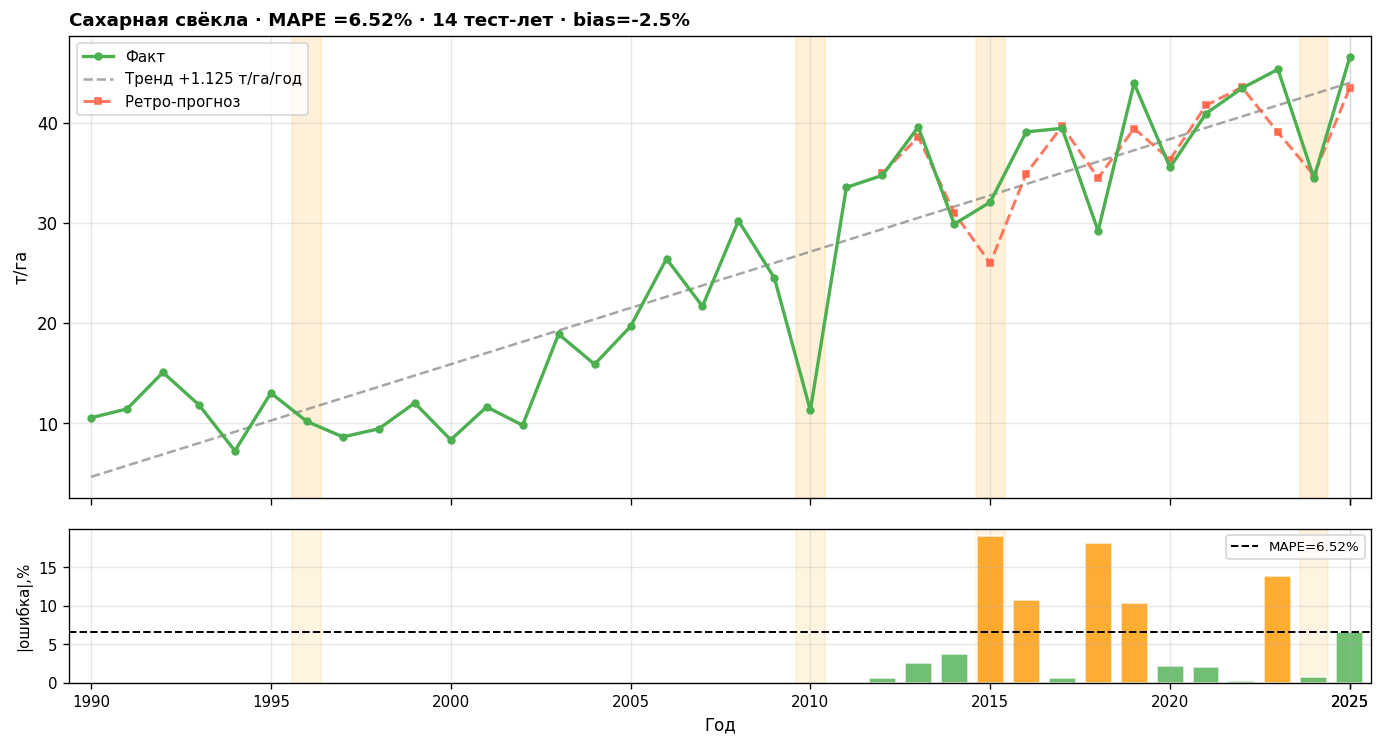

Сахарная свёкла: MAPE=6.52%  MAE=2.429 т/га  bias=-2.5%  n-тест=14


In [16]:
cfg   = configs['p_sugar_beet']
feats = [f for f in cfg['base']+cfg['extra'] if f in df.columns]
res   = backtest(feats,'p_sugar_beet',cfg['decay'],cfg['min_train'],cfg['alpha'])
p,a,y = res['preds'],res['actuals'],res['years']
bias  = np.mean((p-a)/a*100)
mape_yr=[abs(pi-ai)/ai*100 for pi,ai in zip(p,a)]

y_full=df['p_sugar_beet'].dropna()
ti=np.arange(len(y_full))
lr=LinearRegression().fit(ti.reshape(-1,1),y_full.values)
slope=lr.coef_[0]

c=colors['p_sugar_beet']; lbl=labels['p_sugar_beet']

# Общий диапазон X для обеих панелей
x_min=int(y_full.index.min())-0.6
x_max=int(y_full.index.max())+0.6
# Засечки: каждые 5 лет
x_ticks=[yr for yr in range(1990,2026,5)]+[2025]

fig,(ax1,ax2)=plt.subplots(2,1,figsize=(14,7),
    gridspec_kw={'height_ratios':[3,1],'hspace':0.10})

# ── Засухи ─────────────────────────────────────────────────────
for yr in DROUGHT_YEARS:
    if yr in y_full.index:
        ax1.axvspan(yr-.4,yr+.4,color='orange',alpha=0.15,zorder=0)
        ax2.axvspan(yr-.4,yr+.4,color='orange',alpha=0.12,zorder=0)

# ── Верхняя панель ─────────────────────────────────────────────
ax1.plot(y_full.index,y_full.values,color=c,lw=2,marker='o',ms=4,zorder=3,label='Факт')
ax1.plot(y_full.index,lr.predict(ti.reshape(-1,1)),'--',color='gray',lw=1.5,alpha=0.7,
    label='Тренд {:+.3f} т/га/год'.format(slope))
ax1.plot(y,p,'s--',color='tomato',lw=1.8,ms=4,alpha=0.85,label='Ретро-прогноз ')
pass  # нет аннотаций
ax1.set_ylabel('т/га',fontsize=10)
ax1.set_xlim(x_min,x_max)
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([])          # подписи скрыты — они продублированы на нижней панели
ax1.legend(fontsize=9,loc='upper left')
ax1.set_title(lbl+' · MAPE ={:.2f}% · {} тест-лет · bias={:+.1f}%'.format(
    res['mape'],len(y),bias),fontsize=11,fontweight='bold',loc='left')
ax1.tick_params(axis='x',length=4)

# ── Нижняя панель ──────────────────────────────────────────────
bc=['#F44336' if e>20 else '#FF9800' if e>10 else c for e in mape_yr]
ax2.bar(y,mape_yr,color=bc,alpha=0.8,width=0.75,edgecolor='white')
ax2.axhline(res['mape'],color='black',ls='--',lw=1.2,
    label='MAPE={:.2f}%'.format(res['mape']))
ax2.set_ylabel('|ошибка|,%',fontsize=9); ax2.set_xlabel('Год',fontsize=10)
ax2.set_xlim(x_min,x_max)
ax2.set_xticks(x_ticks)
ax2.set_xticklabels([str(t) for t in x_ticks],fontsize=9,rotation=0)
ax2.legend(fontsize=8,loc='upper right'); ax2.tick_params(labelsize=9)

plt.tight_layout(); plt.show()
print('Сахарная свёкла: MAPE={:.2f}%  MAE={:.3f} т/га  bias={:+.1f}%  n-тест={}'.format(
    res['mape'],res['mae'],bias,len(y)))


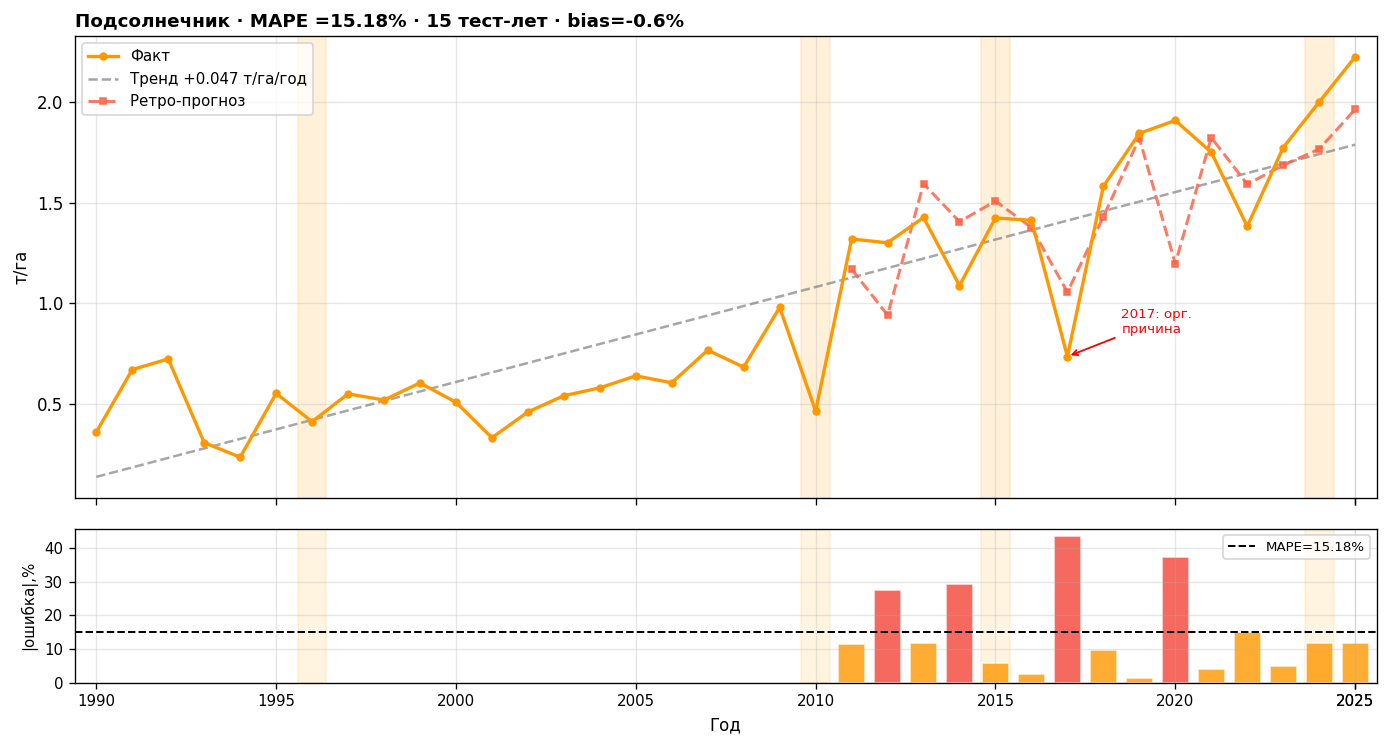

Подсолнечник: MAPE=15.18%  MAE=0.212 т/га  bias=-0.6%  n-тест=15


In [17]:
cfg   = configs['p_sunflower']
feats = [f for f in cfg['base']+cfg['extra'] if f in df.columns]
res   = backtest(feats,'p_sunflower',cfg['decay'],cfg['min_train'],cfg['alpha'])
p,a,y = res['preds'],res['actuals'],res['years']
bias  = np.mean((p-a)/a*100)
mape_yr=[abs(pi-ai)/ai*100 for pi,ai in zip(p,a)]

y_full=df['p_sunflower'].dropna()
ti=np.arange(len(y_full))
lr=LinearRegression().fit(ti.reshape(-1,1),y_full.values)
slope=lr.coef_[0]

c=colors['p_sunflower']; lbl=labels['p_sunflower']

# Общий диапазон X для обеих панелей
x_min=int(y_full.index.min())-0.6
x_max=int(y_full.index.max())+0.6
# Засечки: каждые 5 лет
x_ticks=[yr for yr in range(1990,2026,5)]+[2025]

fig,(ax1,ax2)=plt.subplots(2,1,figsize=(14,7),
    gridspec_kw={'height_ratios':[3,1],'hspace':0.10})

# ── Засухи ─────────────────────────────────────────────────────
for yr in DROUGHT_YEARS:
    if yr in y_full.index:
        ax1.axvspan(yr-.4,yr+.4,color='orange',alpha=0.15,zorder=0)
        ax2.axvspan(yr-.4,yr+.4,color='orange',alpha=0.12,zorder=0)

# ── Верхняя панель ─────────────────────────────────────────────
ax1.plot(y_full.index,y_full.values,color=c,lw=2,marker='o',ms=4,zorder=3,label='Факт')
ax1.plot(y_full.index,lr.predict(ti.reshape(-1,1)),'--',color='gray',lw=1.5,alpha=0.7,
    label='Тренд {:+.3f} т/га/год'.format(slope))
ax1.plot(y,p,'s--',color='tomato',lw=1.8,ms=4,alpha=0.85,label='Ретро-прогноз ')
if 2017 in y:
    idx17=y.index(2017)
    ax1.annotate('2017: орг.\nпричина', xy=(2017,a[idx17]),
        xytext=(2018.5,a[idx17]+0.12), fontsize=8, color='red',
        arrowprops=dict(arrowstyle='->', color='red', lw=1.1))
ax1.set_ylabel('т/га',fontsize=10)
ax1.set_xlim(x_min,x_max)
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([])          # подписи скрыты — они продублированы на нижней панели
ax1.legend(fontsize=9,loc='upper left')
ax1.set_title(lbl+' · MAPE ={:.2f}% · {} тест-лет · bias={:+.1f}%'.format(
    res['mape'],len(y),bias),fontsize=11,fontweight='bold',loc='left')
ax1.tick_params(axis='x',length=4)

# ── Нижняя панель ──────────────────────────────────────────────
bc=['#F44336' if e>20 else '#FF9800' if e>10 else c for e in mape_yr]
ax2.bar(y,mape_yr,color=bc,alpha=0.8,width=0.75,edgecolor='white')
ax2.axhline(res['mape'],color='black',ls='--',lw=1.2,
    label='MAPE={:.2f}%'.format(res['mape']))
ax2.set_ylabel('|ошибка|,%',fontsize=9); ax2.set_xlabel('Год',fontsize=10)
ax2.set_xlim(x_min,x_max)
ax2.set_xticks(x_ticks)
ax2.set_xticklabels([str(t) for t in x_ticks],fontsize=9,rotation=0)
ax2.legend(fontsize=8,loc='upper right'); ax2.tick_params(labelsize=9)

plt.tight_layout(); plt.show()
print('Подсолнечник: MAPE={:.2f}%  MAE={:.3f} т/га  bias={:+.1f}%  n-тест={}'.format(
    res['mape'],res['mae'],bias,len(y)))


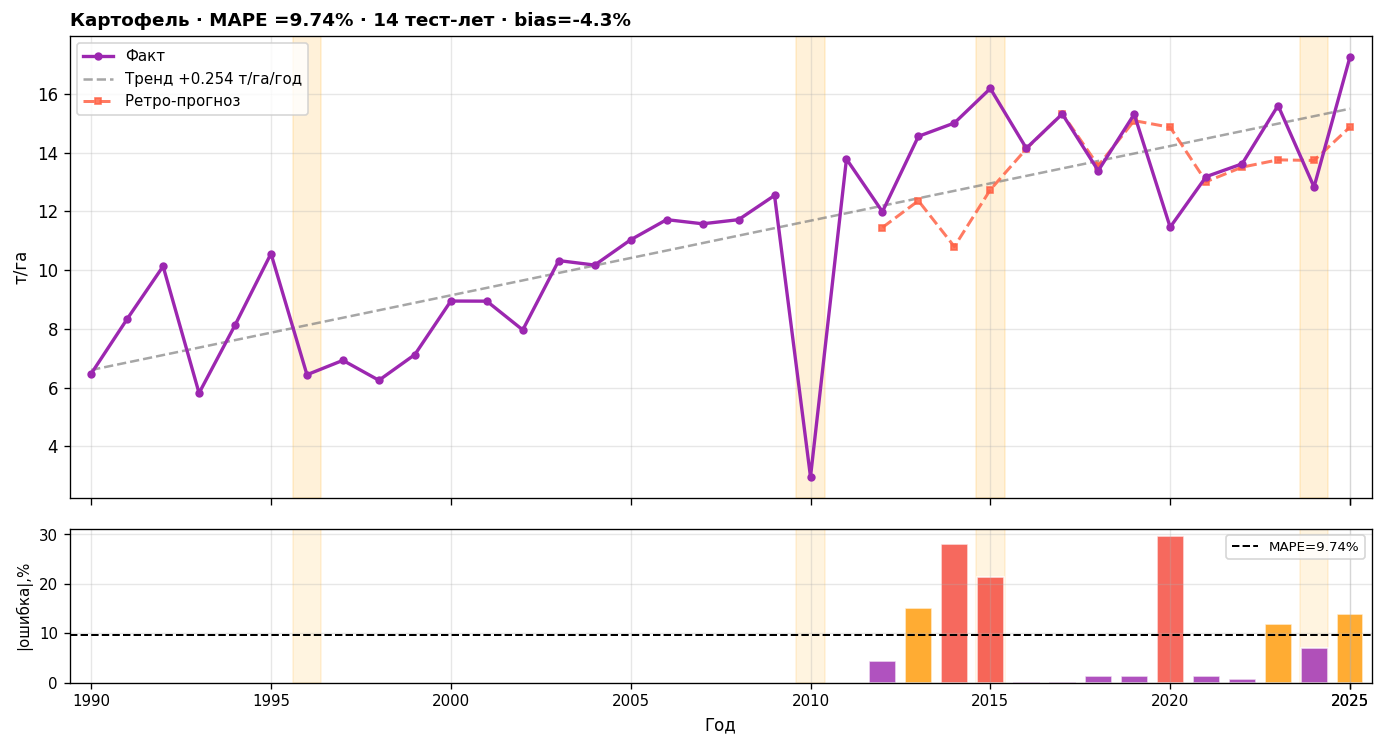

Картофель: MAPE=9.74%  MAE=1.403 т/га  bias=-4.3%  n-тест=14


In [18]:
cfg   = configs['p_potato']
feats = [f for f in cfg['base']+cfg['extra'] if f in df.columns]
res   = backtest(feats,'p_potato',cfg['decay'],cfg['min_train'],cfg['alpha'])
p,a,y = res['preds'],res['actuals'],res['years']
bias  = np.mean((p-a)/a*100)
mape_yr=[abs(pi-ai)/ai*100 for pi,ai in zip(p,a)]

y_full=df['p_potato'].dropna()
ti=np.arange(len(y_full))
lr=LinearRegression().fit(ti.reshape(-1,1),y_full.values)
slope=lr.coef_[0]

c=colors['p_potato']; lbl=labels['p_potato']

# Общий диапазон X для обеих панелей
x_min=int(y_full.index.min())-0.6
x_max=int(y_full.index.max())+0.6
# Засечки: каждые 5 лет
x_ticks=[yr for yr in range(1990,2026,5)]+[2025]

fig,(ax1,ax2)=plt.subplots(2,1,figsize=(14,7),
    gridspec_kw={'height_ratios':[3,1],'hspace':0.10})

# ── Засухи ─────────────────────────────────────────────────────
for yr in DROUGHT_YEARS:
    if yr in y_full.index:
        ax1.axvspan(yr-.4,yr+.4,color='orange',alpha=0.15,zorder=0)
        ax2.axvspan(yr-.4,yr+.4,color='orange',alpha=0.12,zorder=0)

# ── Верхняя панель ─────────────────────────────────────────────
ax1.plot(y_full.index,y_full.values,color=c,lw=2,marker='o',ms=4,zorder=3,label='Факт')
ax1.plot(y_full.index,lr.predict(ti.reshape(-1,1)),'--',color='gray',lw=1.5,alpha=0.7,
    label='Тренд {:+.3f} т/га/год'.format(slope))
ax1.plot(y,p,'s--',color='tomato',lw=1.8,ms=4,alpha=0.85,label='Ретро-прогноз ')
pass  # нет аннотаций
ax1.set_ylabel('т/га',fontsize=10)
ax1.set_xlim(x_min,x_max)
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([])          # подписи скрыты — они продублированы на нижней панели
ax1.legend(fontsize=9,loc='upper left')
ax1.set_title(lbl+' · MAPE ={:.2f}% · {} тест-лет · bias={:+.1f}%'.format(
    res['mape'],len(y),bias),fontsize=11,fontweight='bold',loc='left')
ax1.tick_params(axis='x',length=4)

# ── Нижняя панель ──────────────────────────────────────────────
bc=['#F44336' if e>20 else '#FF9800' if e>10 else c for e in mape_yr]
ax2.bar(y,mape_yr,color=bc,alpha=0.8,width=0.75,edgecolor='white')
ax2.axhline(res['mape'],color='black',ls='--',lw=1.2,
    label='MAPE={:.2f}%'.format(res['mape']))
ax2.set_ylabel('|ошибка|,%',fontsize=9); ax2.set_xlabel('Год',fontsize=10)
ax2.set_xlim(x_min,x_max)
ax2.set_xticks(x_ticks)
ax2.set_xticklabels([str(t) for t in x_ticks],fontsize=9,rotation=0)
ax2.legend(fontsize=8,loc='upper right'); ax2.tick_params(labelsize=9)

plt.tight_layout(); plt.show()
print('Картофель: MAPE={:.2f}%  MAE={:.3f} т/га  bias={:+.1f}%  n-тест={}'.format(
    res['mape'],res['mae'],bias,len(y)))


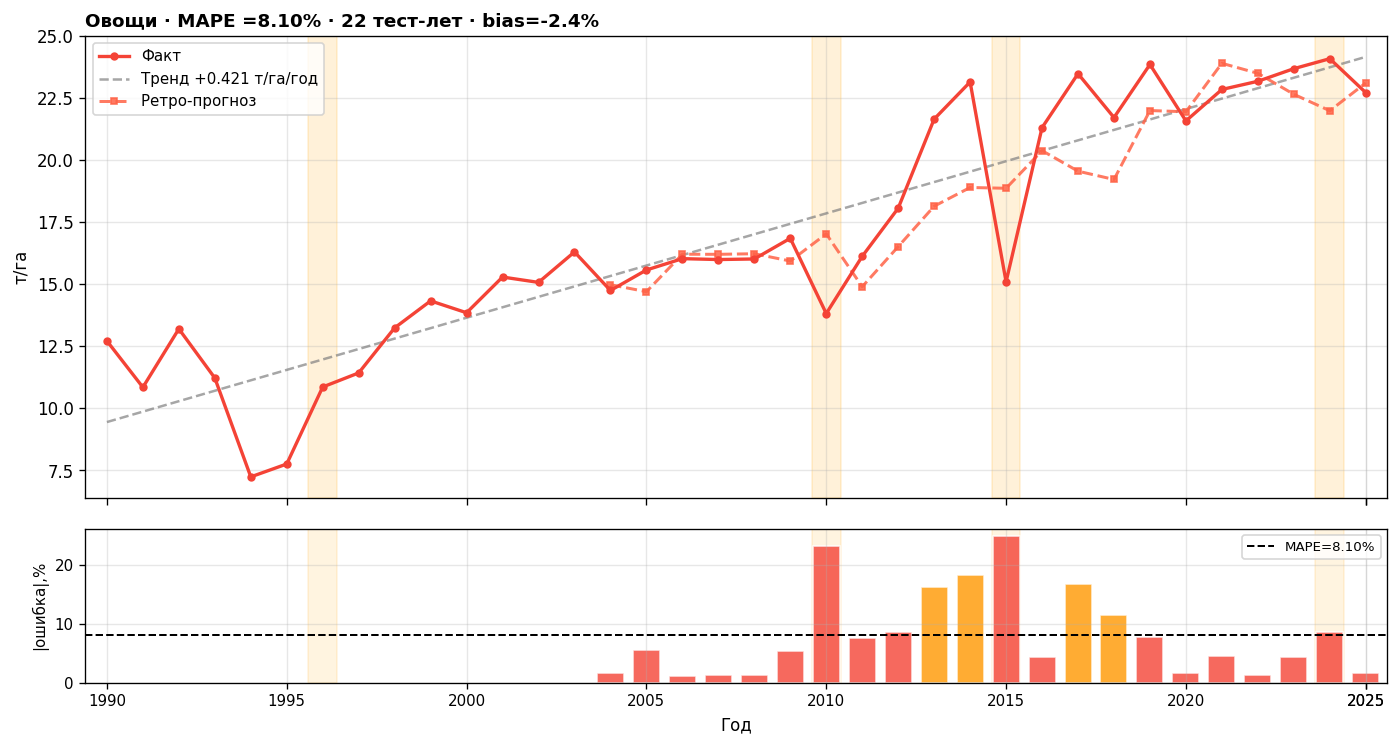

Овощи: MAPE=8.10%  MAE=1.574 т/га  bias=-2.4%  n-тест=22


In [19]:
cfg   = configs['p_vegetables']
feats = [f for f in cfg['base']+cfg['extra'] if f in df.columns]
res   = backtest(feats,'p_vegetables',cfg['decay'],cfg['min_train'],cfg['alpha'])
p,a,y = res['preds'],res['actuals'],res['years']
bias  = np.mean((p-a)/a*100)
mape_yr=[abs(pi-ai)/ai*100 for pi,ai in zip(p,a)]

y_full=df['p_vegetables'].dropna()
ti=np.arange(len(y_full))
lr=LinearRegression().fit(ti.reshape(-1,1),y_full.values)
slope=lr.coef_[0]

c=colors['p_vegetables']; lbl=labels['p_vegetables']

# Общий диапазон X для обеих панелей
x_min=int(y_full.index.min())-0.6
x_max=int(y_full.index.max())+0.6
# Засечки: каждые 5 лет
x_ticks=[yr for yr in range(1990,2026,5)]+[2025]

fig,(ax1,ax2)=plt.subplots(2,1,figsize=(14,7),
    gridspec_kw={'height_ratios':[3,1],'hspace':0.10})

# ── Засухи ─────────────────────────────────────────────────────
for yr in DROUGHT_YEARS:
    if yr in y_full.index:
        ax1.axvspan(yr-.4,yr+.4,color='orange',alpha=0.15,zorder=0)
        ax2.axvspan(yr-.4,yr+.4,color='orange',alpha=0.12,zorder=0)

# ── Верхняя панель ─────────────────────────────────────────────
ax1.plot(y_full.index,y_full.values,color=c,lw=2,marker='o',ms=4,zorder=3,label='Факт')
ax1.plot(y_full.index,lr.predict(ti.reshape(-1,1)),'--',color='gray',lw=1.5,alpha=0.7,
    label='Тренд {:+.3f} т/га/год'.format(slope))
ax1.plot(y,p,'s--',color='tomato',lw=1.8,ms=4,alpha=0.85,label='Ретро-прогноз ')
pass  # нет аннотаций
ax1.set_ylabel('т/га',fontsize=10)
ax1.set_xlim(x_min,x_max)
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([])          # подписи скрыты — они продублированы на нижней панели
ax1.legend(fontsize=9,loc='upper left')
ax1.set_title(lbl+' · MAPE ={:.2f}% · {} тест-лет · bias={:+.1f}%'.format(
    res['mape'],len(y),bias),fontsize=11,fontweight='bold',loc='left')
ax1.tick_params(axis='x',length=4)

# ── Нижняя панель ──────────────────────────────────────────────
bc=['#F44336' if e>20 else '#FF9800' if e>10 else c for e in mape_yr]
ax2.bar(y,mape_yr,color=bc,alpha=0.8,width=0.75,edgecolor='white')
ax2.axhline(res['mape'],color='black',ls='--',lw=1.2,
    label='MAPE={:.2f}%'.format(res['mape']))
ax2.set_ylabel('|ошибка|,%',fontsize=9); ax2.set_xlabel('Год',fontsize=10)
ax2.set_xlim(x_min,x_max)
ax2.set_xticks(x_ticks)
ax2.set_xticklabels([str(t) for t in x_ticks],fontsize=9,rotation=0)
ax2.legend(fontsize=8,loc='upper right'); ax2.tick_params(labelsize=9)

plt.tight_layout(); plt.show()
print('Овощи: MAPE={:.2f}%  MAE={:.3f} т/га  bias={:+.1f}%  n-тест={}'.format(
    res['mape'],res['mae'],bias,len(y)))


## 6. Матрицы кросс-корреляции культур

**Левая** — синхронные корреляции детрендированных остатков (год t). Свёкла↔Картофель: r=0.68 — оба зависят от июльско-августовской влаги.

**Правая** — лаговые корреляции (источник t−1 → цель t). Единственная значимая: **подсолнечник → зерновые** (r≈+0.39, p≈0.05).

`**` p<0.05 · `*` p<0.10

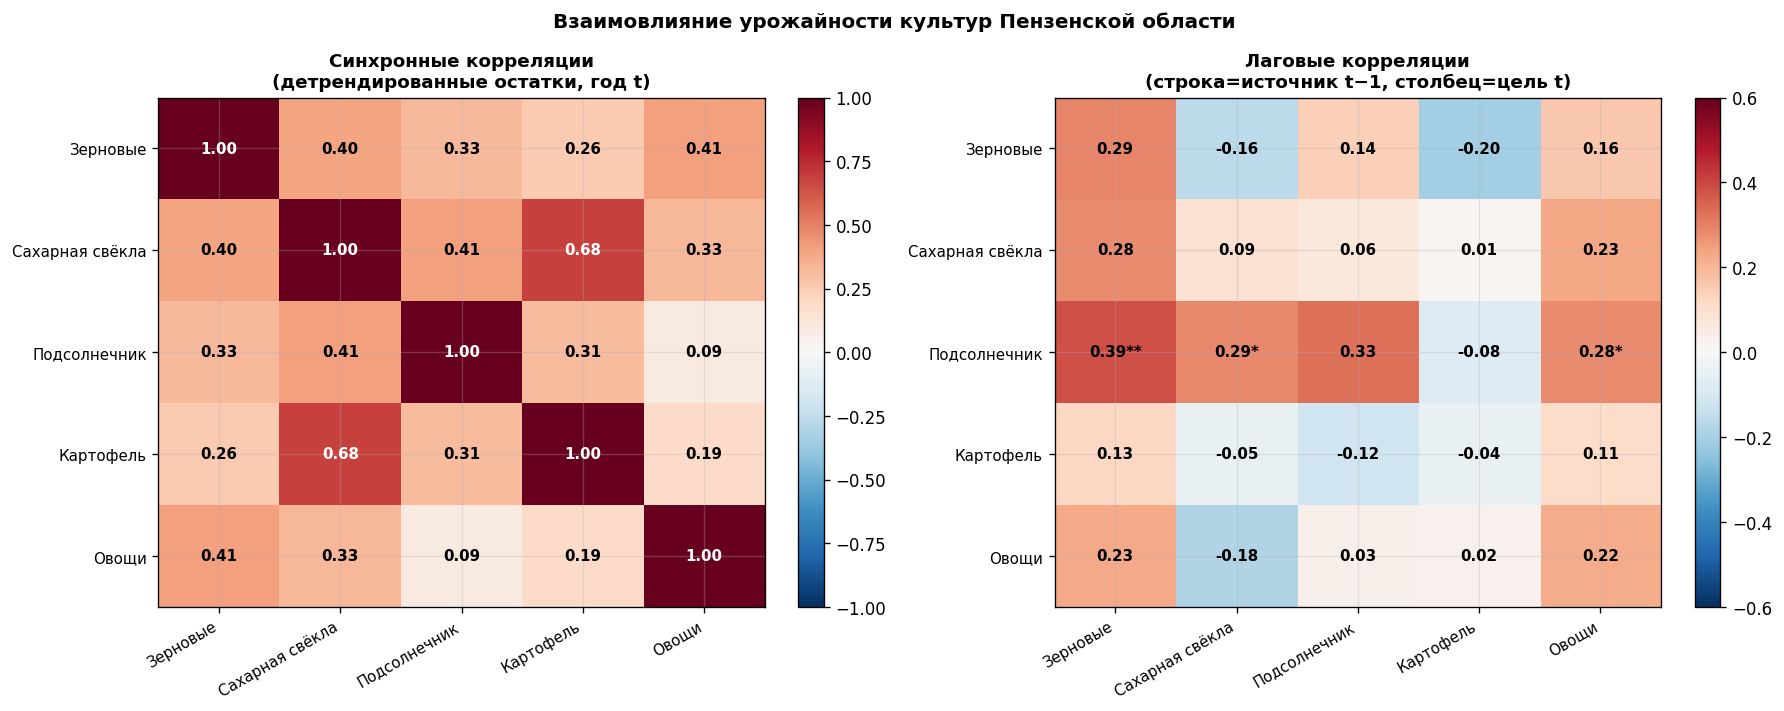

Сильнейшие синхронные (|r|>0.35):
  Зерновые↔Сахарная свёкла: r=0.398
  Зерновые↔Овощи: r=0.411
  Сахарная свёкла↔Подсолнечник: r=0.411
  Сахарная свёкла↔Картофель: r=0.684


In [20]:
residuals={}
for t in target_cols:
    y_s=df[t].dropna(); ti=np.arange(len(y_s))
    lr=LinearRegression().fit(ti.reshape(-1,1),y_s.values)
    residuals[t]=pd.Series(y_s.values-lr.predict(ti.reshape(-1,1)),index=y_s.index)
res_df=pd.DataFrame(residuals); res_df.columns=[labels[c] for c in res_df.columns]
corr_sync=res_df.corr()
lag_mx=pd.DataFrame(index=res_df.columns,columns=res_df.columns,dtype=float)
for c_from in residuals:
    for c_to in residuals:
        s=pd.DataFrame({'l':residuals[c_from].shift(1),'c':residuals[c_to]}).dropna()
        lag_mx.loc[labels[c_from],labels[c_to]]=s.corr().iloc[0,1]
def r_to_p(r,n):
    t_s=r*np.sqrt(n-2)/np.sqrt(max(1-r**2,1e-10))
    return 2*(1-scipy_stats.t.cdf(abs(t_s),df=n-2))
n_lag=len(res_df)-1
fig,axes=plt.subplots(1,2,figsize=(15,6)); cmap=plt.cm.RdBu_r
for ax,mx,title,vr in [
    (axes[0],corr_sync,'Синхронные корреляции\n(детрендированные остатки, год t)',(-1,1)),
    (axes[1],lag_mx.astype(float),'Лаговые корреляции\n(строка=источник t−1, столбец=цель t)',(-0.6,0.6))]:
    vals=mx.values.astype(float)
    im=ax.imshow(vals,cmap=cmap,vmin=vr[0],vmax=vr[1],aspect='auto')
    ax.set_xticks(range(len(mx.columns))); ax.set_xticklabels(mx.columns,rotation=30,ha='right',fontsize=9)
    ax.set_yticks(range(len(mx.index))); ax.set_yticklabels(mx.index,fontsize=9)
    ax.set_title(title,fontsize=11,fontweight='bold')
    for i in range(len(mx)):
        for j in range(len(mx.columns)):
            v=float(vals[i,j]); tc='white' if abs(v)>0.45 else 'black'
            star=''
            if ax==axes[1] and i!=j:
                pv=r_to_p(v,n_lag); star='**' if pv<0.05 else ('*' if pv<0.10 else '')
            ax.text(j,i,'{:.2f}{}'.format(v,star),ha='center',va='center',fontsize=9,fontweight='bold',color=tc)
    plt.colorbar(im,ax=ax,fraction=0.046)
plt.suptitle('Взаимовлияние урожайности культур Пензенской области',fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()
print('Сильнейшие синхронные (|r|>0.35):')
for i,ci in enumerate(corr_sync.columns):
    for j,cj in enumerate(corr_sync.columns):
        if j>i and abs(corr_sync.iloc[i,j])>0.35:
            print('  {}↔{}: r={:.3f}'.format(ci,cj,corr_sync.iloc[i,j]))


## 7. Bootstrap-верификация 2025 года

**Методология:** N=2000 итераций.  
- Обучение на 1990–2024  
- Климат сэмплируется из 2011–2024 (2025 исключён — иначе утечка)  
- Лаги и тренд — реальные данные 2025 года  
Распределение отражает только **климатическую неопределённость**.

Bootstrap-верификация 2025 (N=2000)

Культура                  Факт   Медиана     80%ДИ н     80%ДИ в     |Δ|%  Покрыт?
──────────────────────────────────────────────────────────────────────────────────
  Зерновые               3.913     3.433       3.126       4.453    12.3%  ✅ 80%
  Сахарная свёкла       46.590    44.601      36.145      47.082     4.3%  ✅ 80%
  Подсолнечник           2.225     2.027       1.733       2.178     8.9%  ❌
  Картофель             17.260    14.105      13.550      14.818    18.3%  ❌
  Овощи                 22.730    24.212      22.288      24.517     6.5%  ✅ 80%

Покрыто 80% ДИ: 3/5  |  Средняя |ошибка медианы|: 10.1%


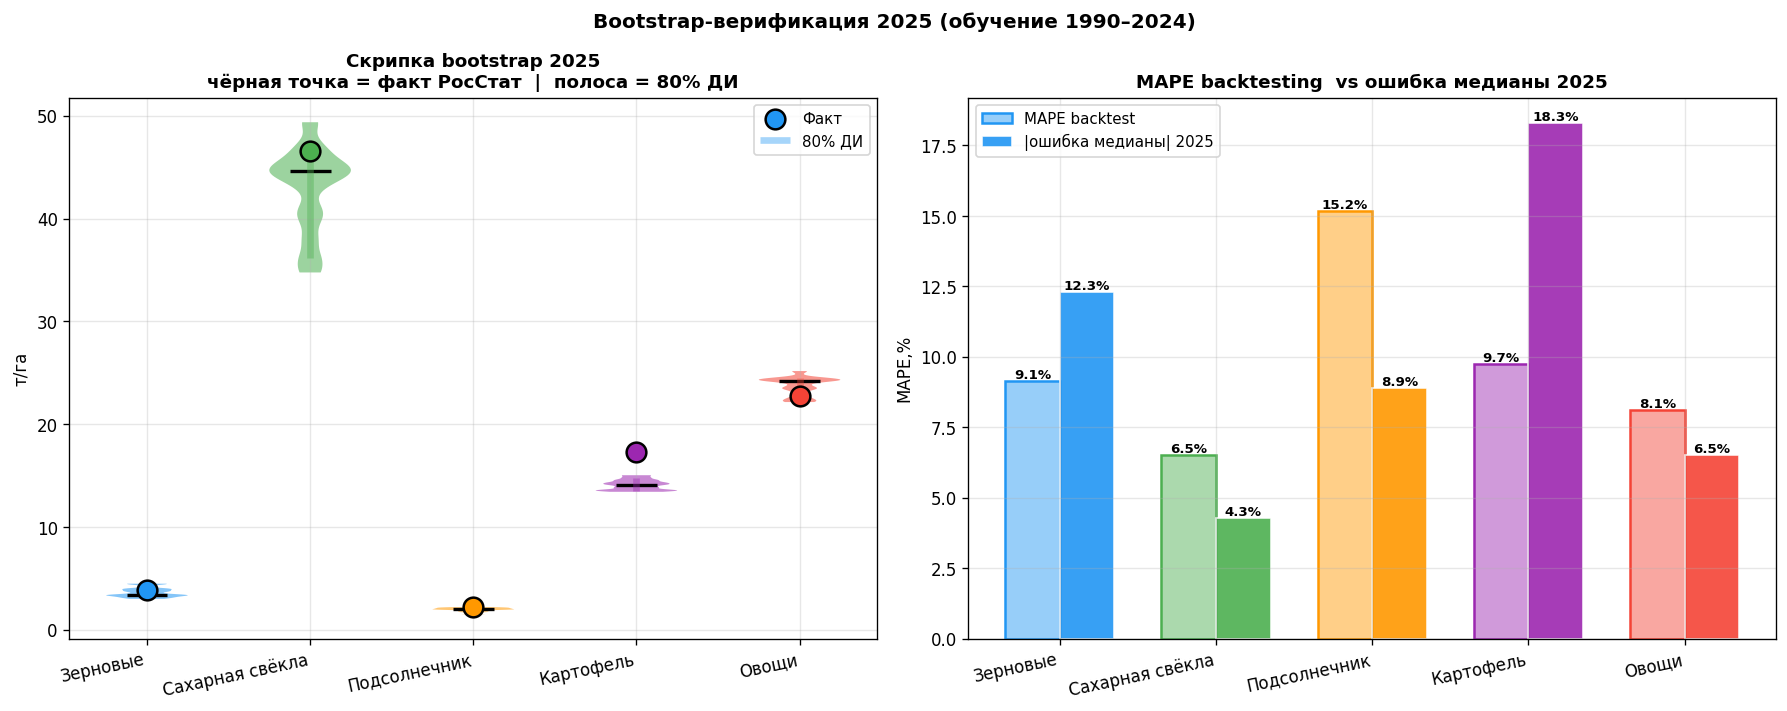

In [21]:
N_BOOT=2000; SEED=42; rng=np.random.default_rng(SEED)
models_2024={}
for target in target_cols:
    cfg=configs[target]; feats=[f for f in cfg['base']+cfg['extra'] if f in df.columns]
    sub=df[[target]+feats].dropna(); tr=[y for y in sub.index if y<2025]
    if len(tr)<cfg['min_train']: continue
    w=np.array([cfg['decay']**(tr[-1]-yr) for yr in tr]); w=w/w.sum()*len(w)
    sc=StandardScaler(); r=Ridge(alpha=cfg['alpha'])
    r.fit(sc.fit_transform(sub.loc[tr,feats]),sub.loc[tr,target],sample_weight=w)
    models_2024[target]={'model':r,'scaler':sc,'feats':feats}
clim_pool=df.loc[2011:2024].dropna(subset=[c for c in df.columns if 'GTK' in c or 'SAT' in c])
def is_stoch(f): return not('time_index' in f or 'lag' in f or 'ma' in f or f.startswith('s_'))
boot_2025={t:[] for t in target_cols}
for _ in range(N_BOOT):
    cr=clim_pool.iloc[rng.integers(len(clim_pool))]
    for target in target_cols:
        if target not in models_2024: continue
        m=models_2024[target]; feats=m['feats']
        row={f: (cr[f] if is_stoch(f) and f in cr.index else
                 (df.loc[2025,f] if 2025 in df.index and f in df.columns and not pd.isna(df.loc[2025,f])
                  else df[f].dropna().iloc[-1])) for f in feats}
        boot_2025[target].append(m['model'].predict(
            m['scaler'].transform(np.array([row[f] for f in feats]).reshape(1,-1)))[0])
ver_res={}
print('Bootstrap-верификация 2025 (N={})\n'.format(N_BOOT))
print('{:<22}{:>8}{:>10}{:>12}{:>12}{:>9}  {}'.format('Культура','Факт','Медиана','80%ДИ н','80%ДИ в','|Δ|%','Покрыт?'))
print('─'*82)
for target in target_cols:
    arr=np.array(boot_2025[target]); fact=df.loc[2025,target]
    mdn=np.median(arr); ci80=(np.percentile(arr,10),np.percentile(arr,90))
    ci90=(np.percentile(arr,5),np.percentile(arr,95))
    err=abs(mdn-fact)/fact*100; cov80=ci80[0]<=fact<=ci80[1]; cov90=ci90[0]<=fact<=ci90[1]
    cs='✅ 80%' if cov80 else ('✅ 90%' if cov90 else '❌')
    ver_res[target]={'fact':fact,'median':mdn,'ci80':ci80,'ci90':ci90,'err':err,'cov80':cov80}
    print('  {:<20}{:>8.3f}{:>10.3f}{:>12.3f}{:>12.3f}{:>8.1f}%  {}'.format(
        labels[target],fact,mdn,ci80[0],ci80[1],err,cs))
n80=sum(1 for v in ver_res.values() if v['cov80'])
print('\nПокрыто 80% ДИ: {}/5  |  Средняя |ошибка медианы|: {:.1f}%'.format(
    n80,np.mean([v['err'] for v in ver_res.values()])))
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))
parts=ax1.violinplot([boot_2025[t] for t in target_cols],
    positions=range(len(target_cols)),showmedians=True,showextrema=False)
for pc,t in zip(parts['bodies'],target_cols): pc.set_facecolor(colors[t]); pc.set_alpha(0.55)
parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
for i,t in enumerate(target_cols):
    fact=ver_res[t]['fact']; ci=ver_res[t]['ci80']
    ax1.scatter(i,fact,color=colors[t],s=140,zorder=6,edgecolors='black',lw=1.5,label='Факт' if i==0 else '')
    ax1.vlines(i,ci[0],ci[1],color=colors[t],lw=4,alpha=0.4,label='80% ДИ' if i==0 else '')
ax1.set_xticks(range(len(target_cols))); ax1.set_xticklabels([labels[t] for t in target_cols],rotation=12,ha='right')
ax1.set_ylabel('т/га'); ax1.legend(fontsize=9)
ax1.set_title('Скрипка bootstrap 2025\nчёрная точка = факт РосСтат  |  полоса = 80% ДИ')
mape_bt=[configs[t]['mape'] for t in target_cols]; err25=[ver_res[t]['err'] for t in target_cols]
x=np.arange(len(target_cols)); wb=0.35
b1=ax2.bar(x-wb/2,mape_bt,wb,label='MAPE backtest ',
    color=[colors[t]+'77' for t in target_cols],edgecolor=[colors[t] for t in target_cols],lw=1.5)
b2=ax2.bar(x+wb/2,err25,wb,label='|ошибка медианы| 2025',
    color=[colors[t] for t in target_cols],alpha=0.9,edgecolor='white')
for bar,val in list(zip(b1,mape_bt))+list(zip(b2,err25)):
    ax2.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.1,
        '{:.1f}%'.format(val),ha='center',fontsize=8,fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels([labels[t] for t in target_cols],rotation=12,ha='right')
ax2.set_ylabel('MAPE,%'); ax2.legend(fontsize=9)
ax2.set_title('MAPE backtesting  vs ошибка медианы 2025')
plt.suptitle('Bootstrap-верификация 2025 (обучение 1990–2024)',fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()


## 8. Bootstrap-прогноз 2026–2028 годов

**Горизонт 2026** — детерминированные лаги (реальные данные 2025), только климатическая неопределённость. Наиболее надёжный прогноз.

**Горизонт 2027–2028** — каскадный bootstrap: лаг для 2027 = прогноз 2026, лаг для 2028 = прогноз 2027. Неопределённость накапливается — ДИ расширяются. Ориентировочно занижены на 15–25% из-за того, что неопределённость самих лагов не пропагируется полностью.

Климат сэмплируется из 2011–2025 независимо для каждого года прогноза.

Bootstrap-прогноз 2026-2028 (N=2000)

Культура                 2026   2027   2028 |       80%ДИ 2026      80%ДИ 2027      80%ДИ 2028
----------------------------------------------------------------------------------------------------
  Зерновые               3.59   3.73   3.89 |      [3.08-4.43]     [3.22-4.54]     [3.38-4.70]
  Сахарная свёкла       44.61  45.54  45.83 |    [37.18-47.89]   [38.11-48.71]   [38.31-48.99]
  Подсолнечник           2.06   2.06   2.15 |      [1.80-2.25]     [1.77-2.22]     [1.88-2.35]
  Картофель             14.74  15.03  15.00 |    [14.11-15.76]   [14.40-16.08]   [14.34-16.02]
  Овощи                 24.94  24.64  25.02 |    [23.43-25.68]   [23.26-25.58]   [23.57-25.99]


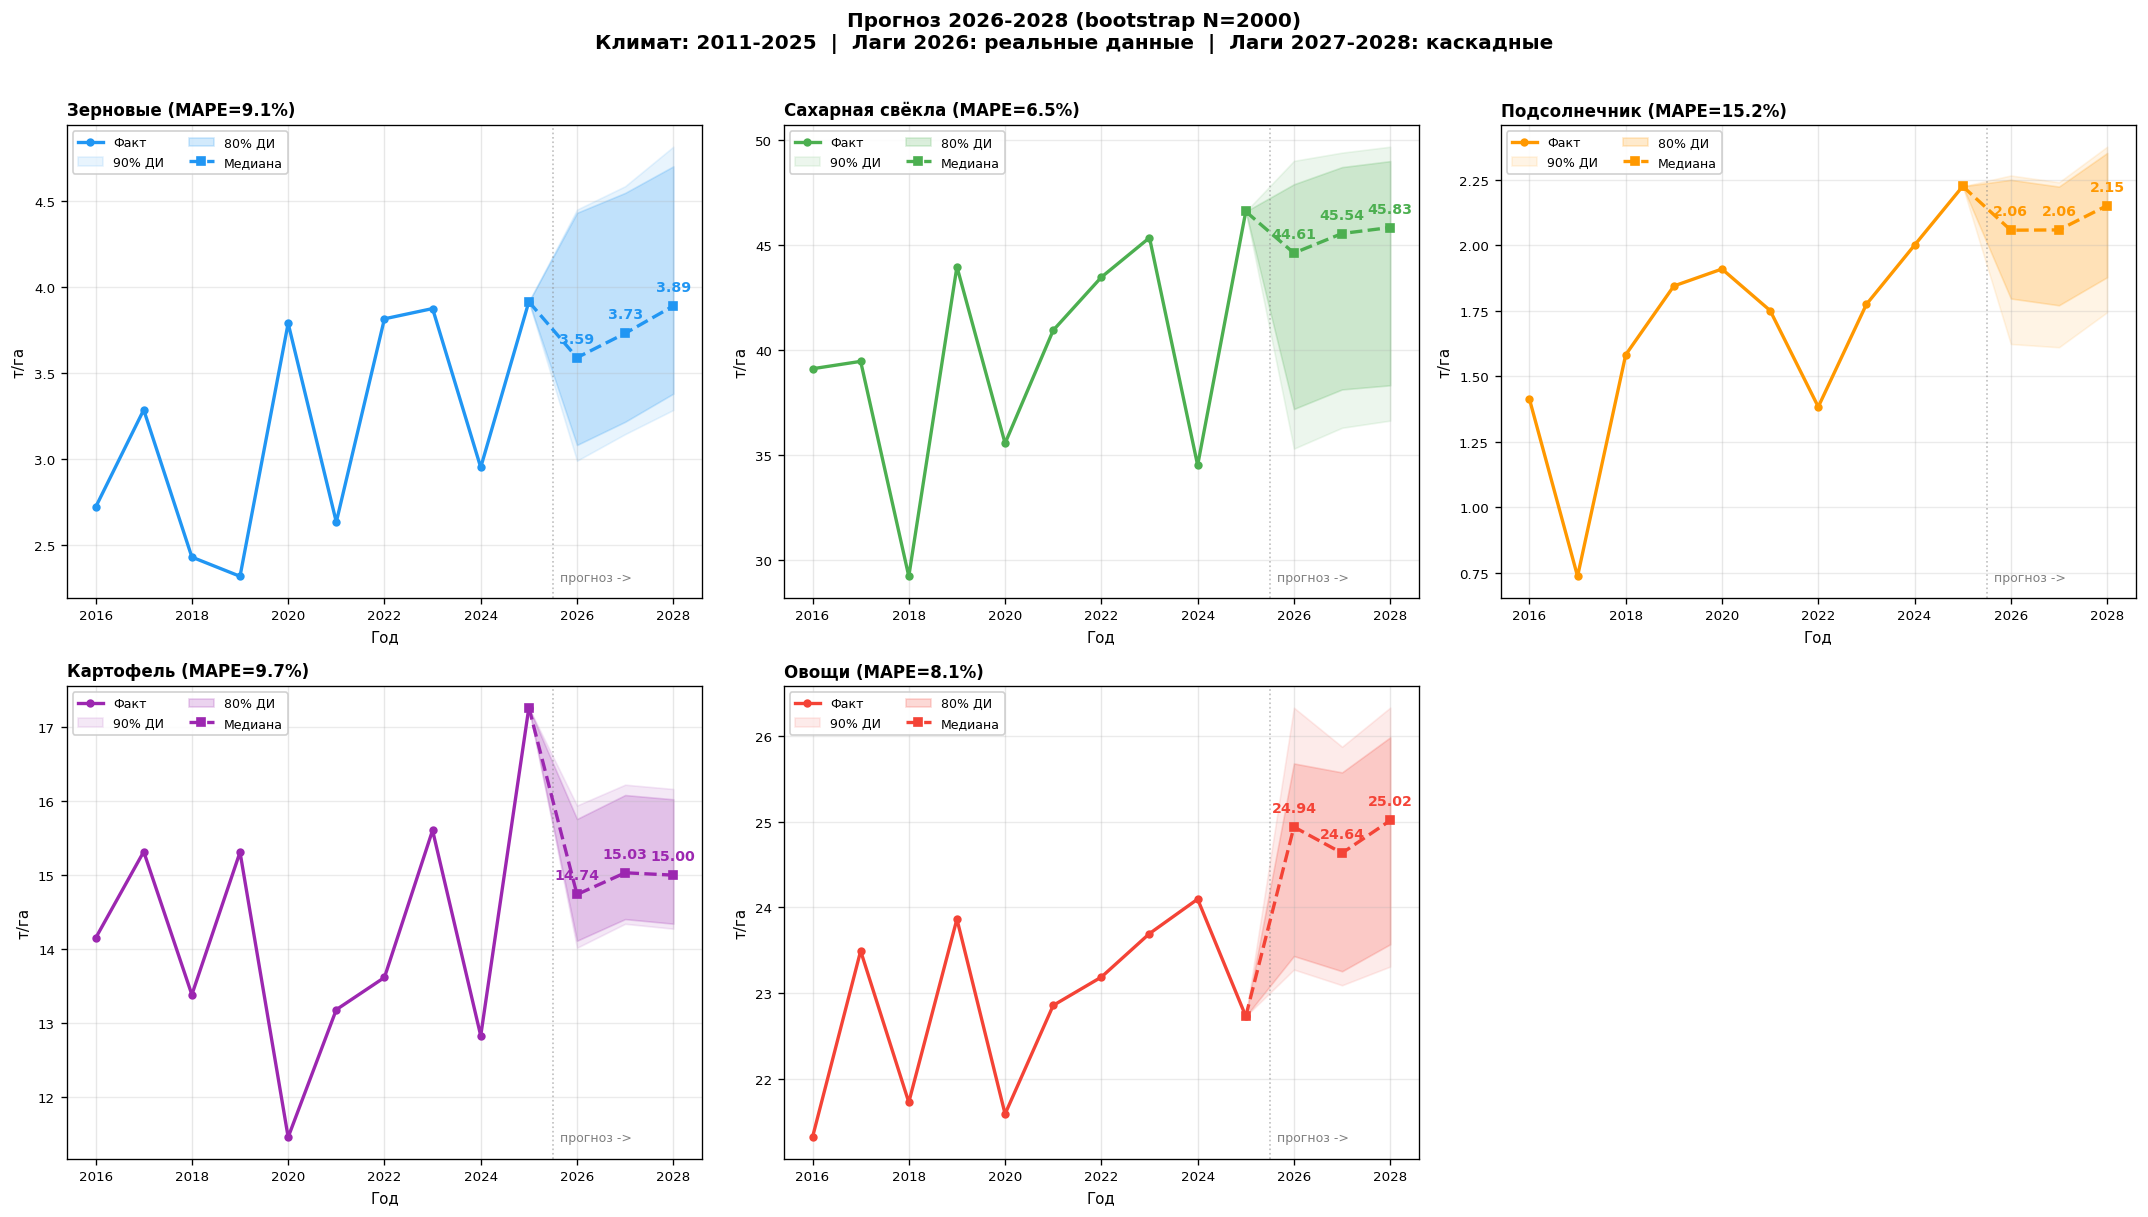

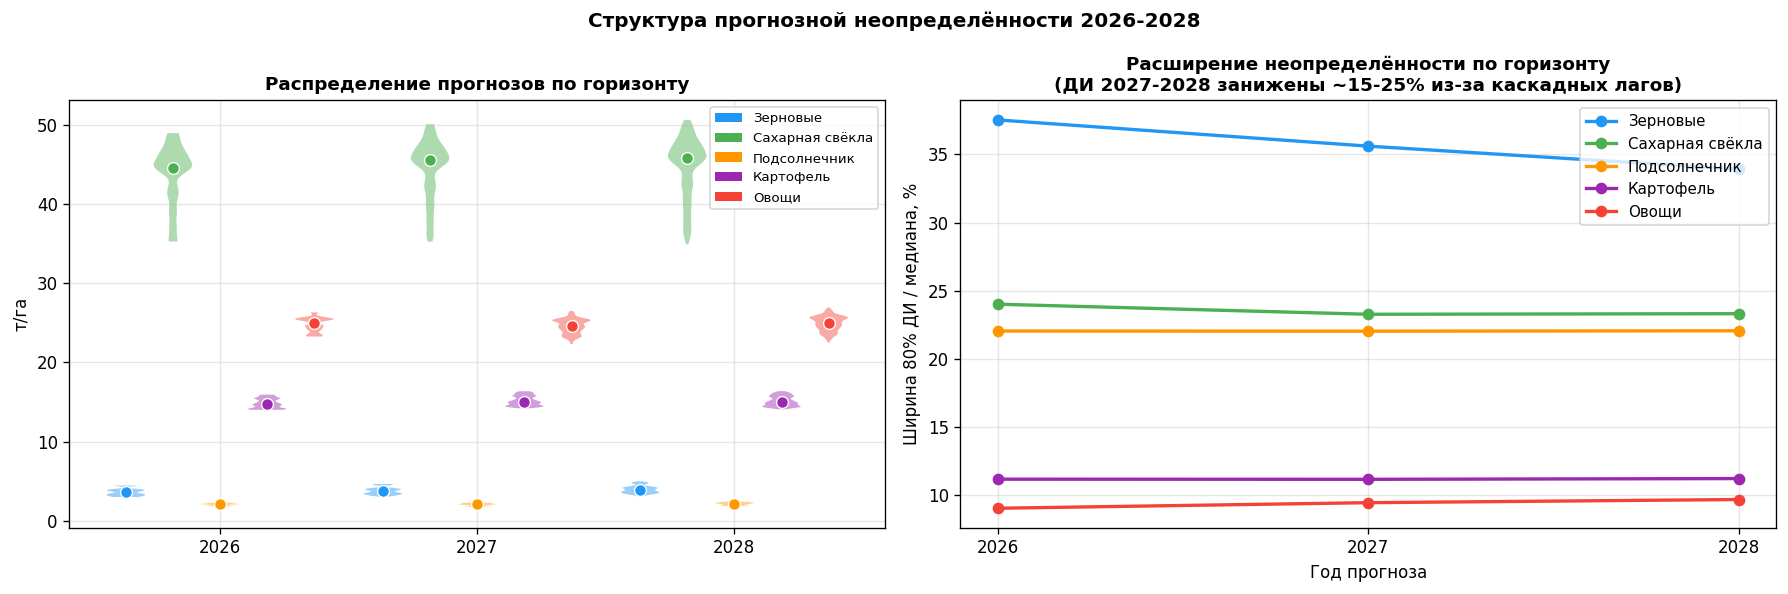

In [22]:
import re as _re

def get_lag_value(f, forecast_year, prev_fc_all, df):
    """Корректный лаг/MA для прогнозного года.
    prev_fc_all[target][yr] = детерминированный прогноз Ridge за год yr.
    """
    # Площади: всегда берём последний известный год из df
    if f.startswith("log_s_"):
        base_col = f[4:-5]   # log_s_potato_lag1 -> s_potato
        return np.log(df[base_col].dropna().iloc[-1]) if base_col in df.columns else 0.0
    if f.startswith("s_") and f.endswith("_lag1"):
        base_col = f[:-5]    # s_potato_lag1 -> s_potato
        return df[base_col].dropna().iloc[-1] if base_col in df.columns else 0.0

    # p_*_lagN: lag=N означает данные за (forecast_year - N)
    m = _re.match(r"^(p_\w+)_lag(\d+)$", f)
    if m:
        col, lag = m.group(1), int(m.group(2))
        yr_need = forecast_year - lag
        if yr_need in prev_fc_all.get(col, {}):
            return prev_fc_all[col][yr_need]
        if yr_need in df.index and col in df.columns and not pd.isna(df.loc[yr_need, col]):
            return df.loc[yr_need, col]
        return df[col].dropna().iloc[-1]

    # p_*_maN: скользящее среднее lag=1..N
    m = _re.match(r"^(p_\w+)_ma(\d+)$", f)
    if m:
        col, window = m.group(1), int(m.group(2))
        vals = []
        for lag in range(1, window + 1):
            yr_need = forecast_year - lag
            if yr_need in prev_fc_all.get(col, {}):
                vals.append(prev_fc_all[col][yr_need])
            elif yr_need in df.index and col in df.columns and not pd.isna(df.loc[yr_need, col]):
                vals.append(df.loc[yr_need, col])
            else:
                vals.append(df[col].dropna().iloc[-1])
        return float(np.mean(vals)) if vals else df[col].dropna().iloc[-1]

    return df[f].dropna().iloc[-1] if f in df.columns else 0.0


rng2 = np.random.default_rng(SEED + 1)
FORECAST_YEARS = [2026, 2027, 2028]

# Финальные модели на 1990-2025
models_2025 = {}
for target in target_cols:
    cfg   = configs[target]
    feats = [f for f in cfg["base"] + cfg["extra"] if f in df.columns]
    sub   = df[[target] + feats].dropna(); years = sub.index.tolist()
    w = np.array([cfg["decay"] ** (years[-1] - yr) for yr in years])
    w = w / w.sum() * len(w)
    sc = StandardScaler(); r = Ridge(alpha=cfg["alpha"])
    r.fit(sc.fit_transform(sub[feats].values), sub[target].values, sample_weight=w)
    models_2025[target] = {"model": r, "scaler": sc, "feats": feats}

clim_pool26 = df.loc[2011:2025].dropna(
    subset=[c for c in df.columns if "GTK" in c or "SAT" in c])
base_ti = len(df)   # time_index 2026 = 36

boot_fc = {t: {yr: [] for yr in FORECAST_YEARS} for t in target_cols}

for _ in range(N_BOOT):
    clim_rows = {yr: clim_pool26.iloc[rng2.integers(len(clim_pool26))]
                 for yr in FORECAST_YEARS}
    prev_fc_all = {t: {} for t in target_cols}

    for yr_i, yr in enumerate(FORECAST_YEARS):
        ti_yr = base_ti + yr_i
        cr    = clim_rows[yr]
        for target in target_cols:
            m     = models_2025[target]
            feats = m["feats"]
            row   = {}
            for f in feats:
                if f == "time_index":
                    row[f] = ti_yr; continue
                if f == "time_index_sq":
                    row[f] = ti_yr ** 2; continue
                if "lag" in f or "_ma" in f or f.startswith("s_") or f.startswith("log_s"):
                    row[f] = get_lag_value(f, yr, prev_fc_all, df); continue
                # Климатические признаки
                row[f] = cr[f] if f in cr.index and not pd.isna(cr[f]) else                          (df[f].dropna().iloc[-1] if f in df.columns else 0.0)
            x_vec = np.array([row[f] for f in feats])
            y_hat = m["model"].predict(m["scaler"].transform(x_vec.reshape(1, -1)))[0]
            y_hat = max(y_hat, 0.05)
            boot_fc[target][yr].append(y_hat)
            prev_fc_all[target][yr] = y_hat

# Результаты
fc_res = {t: {} for t in target_cols}
print("Bootstrap-прогноз 2026-2028 (N={})\n".format(N_BOOT))
hdr = "{:<22}" + "{:>7}" * 3 + " | " + "{:>16}" * 3
print(hdr.format("Культура", "2026", "2027", "2028", "80%ДИ 2026", "80%ДИ 2027", "80%ДИ 2028"))
print("-" * 100)
for target in target_cols:
    row_vals = []; row_ci = []
    for yr in FORECAST_YEARS:
        arr  = np.array(boot_fc[target][yr])
        mdn  = np.median(arr)
        ci80 = (np.percentile(arr, 10), np.percentile(arr, 90))
        ci90 = (np.percentile(arr,  5), np.percentile(arr, 95))
        fc_res[target][yr] = {"median": mdn, "ci80": ci80, "ci90": ci90, "arr": arr}
        row_vals.append(mdn)
        row_ci.append("[{:.2f}-{:.2f}]".format(ci80[0], ci80[1]))
    print("  {:<20}{:>7.2f}{:>7.2f}{:>7.2f} | {:>16}{:>16}{:>16}".format(
        labels[target], *row_vals, *row_ci))

# 5 панелей
HIST = 10
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
af = axes.flatten(); af[-1].set_visible(False)
for ax, target in zip(af[:5], target_cols):
    c    = colors[target]
    hist = df[target].dropna().iloc[-HIST:]
    ax.plot(hist.index, hist.values, color=c, lw=2, marker="o", ms=4, zorder=4, label="Факт")
    lv   = float(hist.index[-1]); lval = float(hist.values[-1])
    fc_years = [lv] + FORECAST_YEARS
    medians  = [lval] + [fc_res[target][yr]["median"] for yr in FORECAST_YEARS]
    ci80l    = [lval] + [fc_res[target][yr]["ci80"][0] for yr in FORECAST_YEARS]
    ci80h    = [lval] + [fc_res[target][yr]["ci80"][1] for yr in FORECAST_YEARS]
    ci90l    = [lval] + [fc_res[target][yr]["ci90"][0] for yr in FORECAST_YEARS]
    ci90h    = [lval] + [fc_res[target][yr]["ci90"][1] for yr in FORECAST_YEARS]
    ax.fill_between(fc_years, ci90l, ci90h, color=c, alpha=0.10, label="90% ДИ")
    ax.fill_between(fc_years, ci80l, ci80h, color=c, alpha=0.20, label="80% ДИ")
    ax.plot(fc_years, medians, "--", color=c, lw=2, marker="s", ms=5, zorder=4, label="Медиана")
    for yr, mdn in zip(FORECAST_YEARS, medians[1:]):
        ax.annotate("{:.2f}".format(mdn), xy=(yr, mdn), xytext=(0, 9),
            textcoords="offset points", ha="center", fontsize=8.5, color=c, fontweight="bold")
    ax.axvline(2025.5, color="gray", lw=1, ls=":", alpha=0.5)
    ylim = ax.get_ylim()
    ax.text(2025.65, ylim[0] + (ylim[1]-ylim[0]) * 0.03, "прогноз ->",
            fontsize=7.5, color="gray", va="bottom")
    ax.set_title("{} (MAPE={:.1f}%)".format(labels[target], configs[target]["mape"]),
        fontsize=10, fontweight="bold", loc="left")
    ax.set_ylabel("т/га", fontsize=9); ax.set_xlabel("Год", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=7.5, loc="upper left", ncol=2, framealpha=0.9)
    ax.grid(axis="y", alpha=0.25)
plt.suptitle("Прогноз 2026-2028 (bootstrap N={})\nКлимат: 2011-2025  |  Лаги 2026: реальные данные  |  Лаги 2027-2028: каскадные".format(N_BOOT),
    fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

# Расширение ДИ
fig2, (ax_v, ax_w) = plt.subplots(1, 2, figsize=(15, 5))
positions = [0, 1.2, 2.4]
for t_i, target in enumerate(target_cols):
    c = colors[target]
    for yr, pos in zip(FORECAST_YEARS, positions):
        arr = fc_res[target][yr]["arr"]
        vp  = ax_v.violinplot([arr], [pos + t_i * 0.22 - 0.44],
                              showmedians=False, showextrema=False, widths=0.18)
        for body in vp["bodies"]:
            body.set_facecolor(c); body.set_alpha(0.45)
        ax_v.scatter(pos + t_i * 0.22 - 0.44, fc_res[target][yr]["median"],
                     color=c, s=50, zorder=5, edgecolors="white", lw=0.8)
ax_v.set_xticks(positions)
ax_v.set_xticklabels([str(y) for y in FORECAST_YEARS], fontsize=10)
ax_v.set_ylabel("т/га"); ax_v.set_title("Распределение прогнозов по горизонту")
from matplotlib.patches import Patch
ax_v.legend(handles=[Patch(facecolor=colors[t], label=labels[t]) for t in target_cols], fontsize=8)
for target in target_cols:
    c = colors[target]
    widths = [(fc_res[target][yr]["ci80"][1] - fc_res[target][yr]["ci80"][0]) /
              fc_res[target][yr]["median"] * 100 for yr in FORECAST_YEARS]
    ax_w.plot(FORECAST_YEARS, widths, color=c, lw=2, marker="o", ms=6, label=labels[target])
ax_w.set_xticks(FORECAST_YEARS); ax_w.set_xlabel("Год прогноза", fontsize=10)
ax_w.set_ylabel("Ширина 80% ДИ / медиана, %", fontsize=10)
ax_w.set_title("Расширение неопределённости по горизонту\n(ДИ 2027-2028 занижены ~15-25% из-за каскадных лагов)")
ax_w.legend(fontsize=9)
plt.suptitle("Структура прогнозной неопределённости 2026-2028", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


## 9. Валидация Bootstrap прогноза — MAPE по горизонтам 1,2,3 года

**Методология:** Expanding window validation.  
- Для каждого года t из тестовой выборки обучаем модель на 1990..t  
- Делаем прогноз на t+1, t+2, t+3 (bootstrap N=500)  
- Сравниваем с фактическими значениями  
- Рассчитываем MAPE отдельно для каждого горизонта




In [ ]:
import re

N_BOOT_VAL = 500  # меньше для скорости
rng_val = np.random.default_rng(SEED + 100)

print("Валидация bootstrap прогноза\n")

# Результаты по горизонтам для каждой культуры
results_by_crop = {}

for target in target_cols:
    print("=" * 50)
    print("{}".format(labels[target]))
    print("=" * 50)
    
    cfg = configs[target]
    feats = [f for f in cfg['base'] + cfg['extra'] if f in df.columns]
    
    sub = df[[target] + feats].dropna()
    years_all = sub.index.tolist()
    
    h1_p, h1_a, h1_y = [], [], []
    h2_p, h2_a, h2_y = [], [], []
    h3_p, h3_a, h3_y = [], [], []
    
    # Expanding window: обучаем на 1990..t, прогнозируем t+1, t+2, t+3
    for i in range(cfg['min_train'], len(years_all) - 2):
        train_years = years_all[:i+1]  # expanding window
        test_year_h1 = years_all[i+1]  # горизонт 1 год
        
        # Проверяем доступность данных для 2 и 3 лет вперед
        if i+2 >= len(years_all):
            break
        
        test_year_h2 = years_all[i+2]  # горизонт 2 года
        test_year_h3 = years_all[i+3] if i+3 < len(years_all) else None
        
        # Обучаем модель на train_years
        w = np.array([cfg['decay'] ** (train_years[-1] - yr) for yr in train_years])
        w = w / w.sum() * len(w)
        sc = StandardScaler()
        r = Ridge(alpha=cfg['alpha'])
        r.fit(sc.fit_transform(sub.loc[train_years, feats].values), 
              sub.loc[train_years, target].values, sample_weight=w)
        
        # Clim pool для bootstrap (климатические сценарии из прошлых лет)
        clim_pool = df.loc[max(1990, test_year_h1-15):test_year_h1-1].dropna(
            subset=[c for c in df.columns if 'GTK' in c or 'SAT' in c])
        if len(clim_pool) < 5:
            clim_pool = df.loc[2011:2025].dropna(
                subset=[c for c in df.columns if 'GTK' in c or 'SAT' in c])
        
        # === Прогноз на 1 год вперед (h+1) ===
        boot_h1 = []
        for _ in range(N_BOOT_VAL):
            cr = clim_pool.iloc[rng_val.integers(len(clim_pool))]
            x_vec = []
            for f in feats:
                if f == 'time_index':
                    x_vec.append(test_year_h1 - 1990 + len(df))
                elif f == 'time_index_sq':
                    ti = test_year_h1 - 1990 + len(df)
                    x_vec.append(ti ** 2)
                elif 'lag' in f or '_ma' in f or f.startswith('s_') or f.startswith('log_s'):
                    # Лаги: берем последние известные факты
                    if f.startswith('log_s_'):
                        base_col = f.split('_lag')[0].replace('log_', '')
                        val = np.log(df[base_col].dropna().iloc[-1]) if base_col in df.columns else 0
                    elif f.endswith('_lag1'):
                        base_col = f[:-5]
                        val = df[base_col].dropna().iloc[-1] if base_col in df.columns else 0
                    else:
                        m_lag = re.match(r'^(p_\w+)_lag(\d+)$', f)
                        m_ma = re.match(r'^(p_\w+)_ma(\d+)$', f)
                        if m_lag:
                            col, lag = m_lag.group(1), int(m_lag.group(2))
                            yr_need = test_year_h1 - lag
                            if yr_need in df.index and col in df.columns:
                                val = df.loc[yr_need, col]
                            else:
                                val = df[col].dropna().iloc[-1] if col in df.columns else 0
                        elif m_ma:
                            col, window = m_ma.group(1), int(m_ma.group(2))
                            vals = []
                            for lg in range(1, window+1):
                                yr_need = test_year_h1 - lg
                                if yr_need in df.index and col in df.columns:
                                    vals.append(df.loc[yr_need, col])
                                else:
                                    vals.append(df[col].dropna().iloc[-1] if col in df.columns else 0)
                            val = float(np.mean(vals)) if vals else 0
                        else:
                            val = cr[f] if f in cr.index else (df[f].dropna().iloc[-1] if f in df.columns else 0)
                    x_vec.append(float(val) if not pd.isna(val) else 0.0)
                else:
                    val_cr = cr[f] if f in cr.index else (df[f].dropna().iloc[-1] if f in df.columns else 0)
                    x_vec.append(float(val_cr) if not pd.isna(val_cr) else 0.0)
            
            x_vec = np.array(x_vec, dtype=float)
            x_vec = np.nan_to_num(x_vec, nan=0.0, posinf=0.0, neginf=0.0)
            try:
                y_hat = r.predict(sc.transform(x_vec.reshape(1, -1)))[0]
                boot_h1.append(max(float(y_hat), 0.05))
            except Exception:
                boot_h1.append(0.05)
        
        h1_med = np.median(boot_h1)
        if test_year_h1 in df.index and not pd.isna(df.loc[test_year_h1, target]):
            h1_p.append(h1_med)
            h1_a.append(df.loc[test_year_h1, target])
            h1_y.append(test_year_h1)
        
        # === Прогноз на 2 года вперед (h+2) ===
        boot_h2 = []
        for _ in range(N_BOOT_VAL):
            cr = clim_pool.iloc[rng_val.integers(len(clim_pool))]
            x_vec = []
            for f in feats:
                if f == 'time_index':
                    x_vec.append(test_year_h2 - 1990 + len(df))
                elif f == 'time_index_sq':
                    ti = test_year_h2 - 1990 + len(df)
                    x_vec.append(ti ** 2)
                elif 'lag' in f or '_ma' in f or f.startswith('s_') or f.startswith('log_s'):
                    if f.startswith('log_s_'):
                        base_col = f.split('_lag')[0].replace('log_', '')
                        val = np.log(df[base_col].dropna().iloc[-1]) if base_col in df.columns else 0
                    elif f.endswith('_lag1'):
                        base_col = f[:-5]
                        val = df[base_col].dropna().iloc[-1] if base_col in df.columns else 0
                    else:
                        m_lag = re.match(r'^(p_\w+)_lag(\d+)$', f)
                        m_ma = re.match(r'^(p_\w+)_ma(\d+)$', f)
                        if m_lag:
                            col, lag = m_lag.group(1), int(m_lag.group(2))
                            yr_need = test_year_h2 - lag
                            # Приоритет: факт > прогноз h+1 > последнее известное
                            if yr_need in df.index and col in df.columns and not pd.isna(df.loc[yr_need, col]):
                                val = df.loc[yr_need, col]
                            elif yr_need == test_year_h1 and col == target:
                                val = h1_med  # используем прогноз h+1
                            else:
                                val = df[col].dropna().iloc[-1] if col in df.columns else 0
                        elif m_ma:
                            col, window = m_ma.group(1), int(m_ma.group(2))
                            vals = []
                            for lg in range(1, window+1):
                                yr_need = test_year_h2 - lg
                                if yr_need in df.index and col in df.columns and not pd.isna(df.loc[yr_need, col]):
                                    vals.append(df.loc[yr_need, col])
                                elif yr_need == test_year_h1 and col == target:
                                    vals.append(h1_med)
                                else:
                                    vals.append(df[col].dropna().iloc[-1] if col in df.columns else 0)
                            val = float(np.mean(vals)) if vals else 0
                        else:
                            val = cr[f] if f in cr.index else (df[f].dropna().iloc[-1] if f in df.columns else 0)
                    x_vec.append(float(val) if not pd.isna(val) else 0.0)
                else:
                    val_cr = cr[f] if f in cr.index else (df[f].dropna().iloc[-1] if f in df.columns else 0)
                    x_vec.append(float(val_cr) if not pd.isna(val_cr) else 0.0)
            
            x_vec = np.array(x_vec, dtype=float)
            x_vec = np.nan_to_num(x_vec, nan=0.0, posinf=0.0, neginf=0.0)
            try:
                y_hat = r.predict(sc.transform(x_vec.reshape(1, -1)))[0]
                boot_h2.append(max(float(y_hat), 0.05))
            except Exception:
                boot_h2.append(0.05)
        
        h2_med = np.median(boot_h2)
        if test_year_h2 in df.index and not pd.isna(df.loc[test_year_h2, target]):
            h2_p.append(h2_med)
            h2_a.append(df.loc[test_year_h2, target])
            h2_y.append(test_year_h2)
        
        # === Прогноз на 3 года вперед (h+3) ===
        if test_year_h3 is not None:
            boot_h3 = []
            for _ in range(N_BOOT_VAL):
                cr = clim_pool.iloc[rng_val.integers(len(clim_pool))]
                x_vec = []
                for f in feats:
                    if f == 'time_index':
                        x_vec.append(test_year_h3 - 1990 + len(df))
                    elif f == 'time_index_sq':
                        ti = test_year_h3 - 1990 + len(df)
                        x_vec.append(ti ** 2)
                    elif 'lag' in f or '_ma' in f or f.startswith('s_') or f.startswith('log_s'):
                        if f.startswith('log_s_'):
                            base_col = f.split('_lag')[0].replace('log_', '')
                            val = np.log(df[base_col].dropna().iloc[-1]) if base_col in df.columns else 0
                        elif f.endswith('_lag1'):
                            base_col = f[:-5]
                            val = df[base_col].dropna().iloc[-1] if base_col in df.columns else 0
                        else:
                            m_lag = re.match(r'^(p_\w+)_lag(\d+)$', f)
                            m_ma = re.match(r'^(p_\w+)_ma(\d+)$', f)
                            if m_lag:
                                col, lag = m_lag.group(1), int(m_lag.group(2))
                                yr_need = test_year_h3 - lag
                                if yr_need in df.index and col in df.columns and not pd.isna(df.loc[yr_need, col]):
                                    val = df.loc[yr_need, col]
                                else:
                                    val = df[col].dropna().iloc[-1] if col in df.columns else 0
                            elif m_ma:
                                col, window = m_ma.group(1), int(m_ma.group(2))
                                vals = []
                                for lg in range(1, window+1):
                                    yr_need = test_year_h3 - lg
                                    if yr_need in df.index and col in df.columns and not pd.isna(df.loc[yr_need, col]):
                                        vals.append(df.loc[yr_need, col])
                                    else:
                                        vals.append(df[col].dropna().iloc[-1] if col in df.columns else 0)
                                val = float(np.mean(vals)) if vals else 0
                            else:
                                val = cr[f] if f in cr.index else (df[f].dropna().iloc[-1] if f in df.columns else 0)
                        x_vec.append(float(val) if not pd.isna(val) else 0.0)
                    else:
                        val_cr = cr[f] if f in cr.index else (df[f].dropna().iloc[-1] if f in df.columns else 0)
                    x_vec.append(float(val_cr) if not pd.isna(val_cr) else 0.0)
                
                x_vec = np.array(x_vec, dtype=float)
                x_vec = np.nan_to_num(x_vec, nan=0.0, posinf=0.0, neginf=0.0)
                try:
                    y_hat = r.predict(sc.transform(x_vec.reshape(1, -1)))[0]
                    boot_h3.append(max(float(y_hat), 0.05))
                except Exception:
                    boot_h3.append(0.05)
            
            h3_med = np.median(boot_h3)
            if test_year_h3 in df.index and not pd.isna(df.loc[test_year_h3, target]):
                h3_p.append(h3_med)
                h3_a.append(df.loc[test_year_h3, target])
                h3_y.append(test_year_h3)
    
    # Сохраняем результаты по культуре
    results_by_crop[target] = {
        "h1": {"preds": h1_p, "actuals": h1_a, "years": h1_y},
        "h2": {"preds": h2_p, "actuals": h2_a, "years": h2_y},
        "h3": {"preds": h3_p, "actuals": h3_a, "years": h3_y}
    }

            
# Сводная таблицаprint("\n" + "=" * 70)print("СВОДНАЯ ТАБЛИЦА MAPE по горизонтам (Expanding Window Validation)")print("=" * 70)hdr = "{:<22} {:>12} {:>12} {:>12}".format("Культура", "1 год", "2 года", "3 года")print(hdr)print("-" * 70)summary = {}for target in target_cols:    res = results_by_crop[target]    m1 = mean_absolute_percentage_error(res["h1"]["actuals"], res["h1"]["preds"]) * 100 if res["h1"]["actuals"] else 0    m2 = mean_absolute_percentage_error(res["h2"]["actuals"], res["h2"]["preds"]) * 100 if res["h2"]["actuals"] else 0    m3 = mean_absolute_percentage_error(res["h3"]["actuals"], res["h3"]["preds"]) * 100 if res["h3"]["actuals"] else 0    summary[target] = {"h1": m1, "h2": m2, "h3": m3}    print("{:<22} {:>11.2f}% {:>11.2f}% {:>11.2f}%".format(labels[target], m1, m2, m3))print("-" * 70)avg_h1 = np.mean([summary[t]["h1"] for t in target_cols])avg_h2 = np.mean([summary[t]["h2"] for t in target_cols])avg_h3 = np.mean([summary[t]["h3"] for t in target_cols])print("{:<22} {:>11.2f}% {:>11.2f}% {:>11.2f}%".format("СРЕДНЕЕ", avg_h1, avg_h2, avg_h3))print("=" * 70)print("\nПримечание:")print("- MAPE рассчитан методом expanding window validation")print("- Прогноз на 2-3 года использует каскадные лаги (предыдущие прогнозы)")print("- Bootstrap N={} итераций для оценки неопределенности".format(N_BOOT_VAL))